In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Customer Churn Analysis - Week 1 EDA
**Author**: [Anderia nisar]

**Date**: [4-mar-2026]

**Course**: Introduction to Applied AI

## Project Overview
This notebook performs exploratory data analysis on customer churn data to identify
patterns and inform our predictive modeling approach.
## Table of Contents
1. Dataset Overview
2. Numerical Features Analysis
3. Categorical Features Analysis
4. Feature Correlations
5. Key Insights and Findings


Task 1.3: Load the Dataset

In [3]:
# Load data
df = pd.read_csv('/kaggle/input/datasets/anderianisar/lab1-telco-customer/WA_Fn-UseC_-Telco-Customer-Churn.csv')
# First look
print('Dataset shape:', df.shape)
print('\nFirst 5 rows:')
df.head()


Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Dataset Overview

Task 2.1: Basic Information 

A. Column Information:

In [4]:
# 1.1 Column names and types
print('Column Information:')
df.info()

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

B. Statistical Summary:

In [5]:
# 1.2 Statistical summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# 1.4 Target variable distribution
print('Churn Distribution:')
print(df['Churn'].value_counts())
print('\nChurn Percentage:')
print(df['Churn'].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


### Key Findings:- Dataset has X customers- Churn rate is Y%- Z missing values in TotalCharges column- Features include demographics, services, and account info


## 2. Numerical Features Analysis

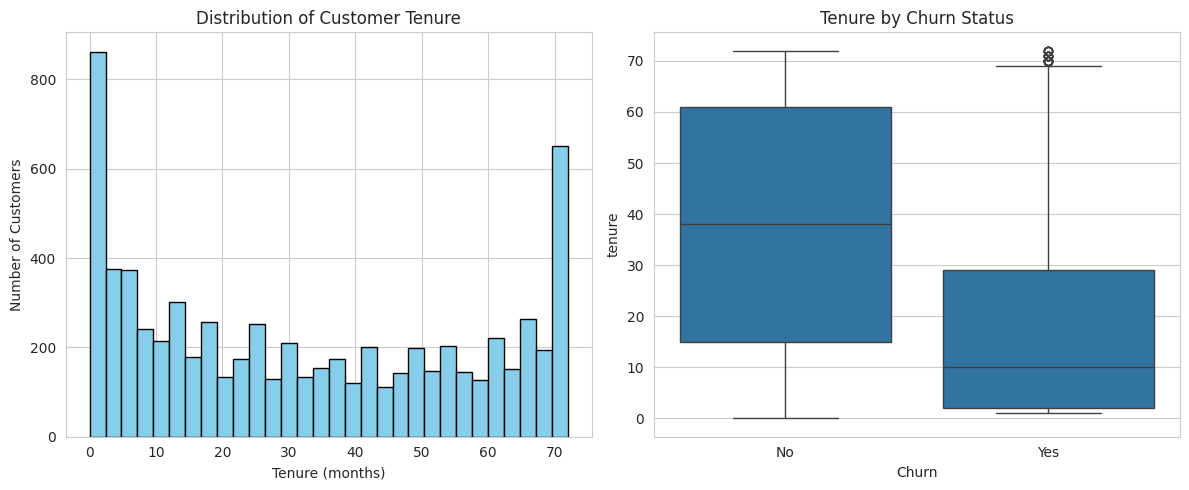

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['tenure'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Tenure')
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure by Churn Status')
plt.tight_layout()
plt.show()


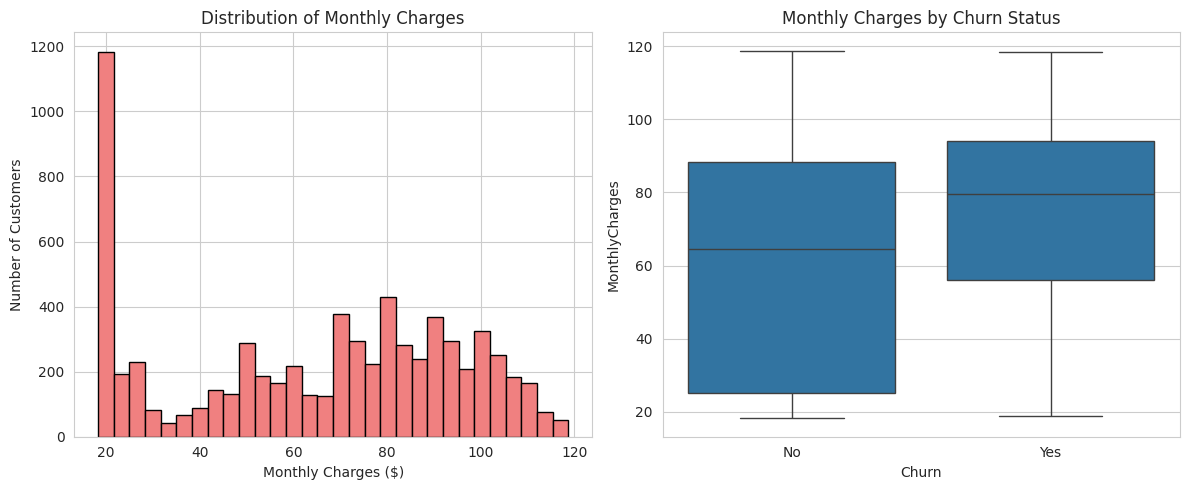

In [8]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['MonthlyCharges'], bins=30, color='lightcoral', edgecolor='black')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Monthly Charges')
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn Status')
plt.tight_layout()
plt.show()


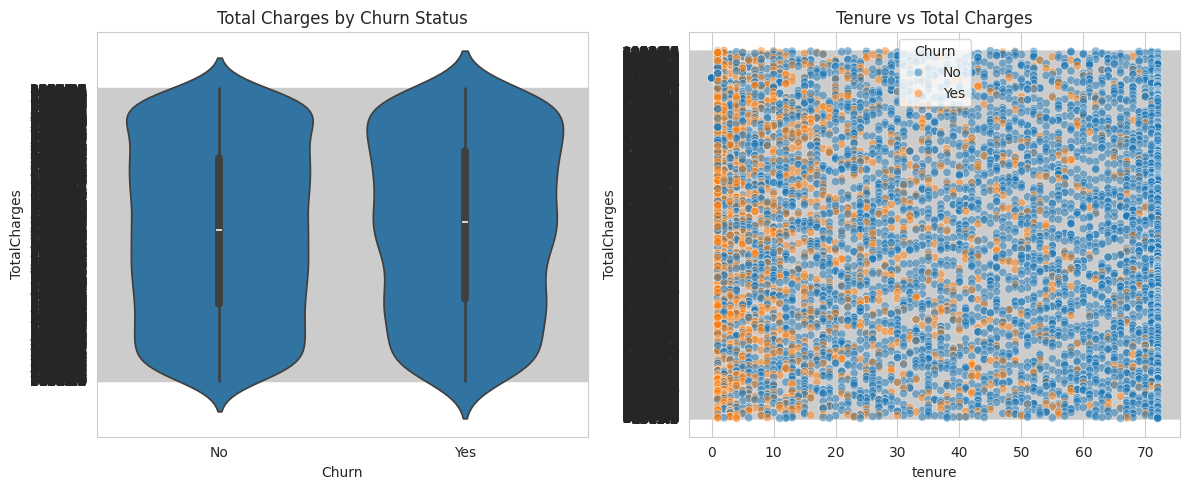

In [9]:
# Remove missing values for this plot
df_clean = df[df['TotalCharges'].notna()]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.violinplot(x='Churn', y='TotalCharges', data=df_clean)
plt.title('Total Charges by Churn Status')
plt.subplot(1, 2, 2)
sns.scatterplot(x='tenure', y='TotalCharges', hue='Churn', data=df_clean,
alpha=0.5)
plt.title('Tenure vs Total Charges')
plt.tight_layout()
plt.show()


al Features Insights:- Tenure: Customers with shorter tenure more likely to churn- Monthly Charges: Higher charges correlate with higher churn- Total Charges: Related to tenure (longer tenure = higher total charges)

## 3. Categorical Features Analysis

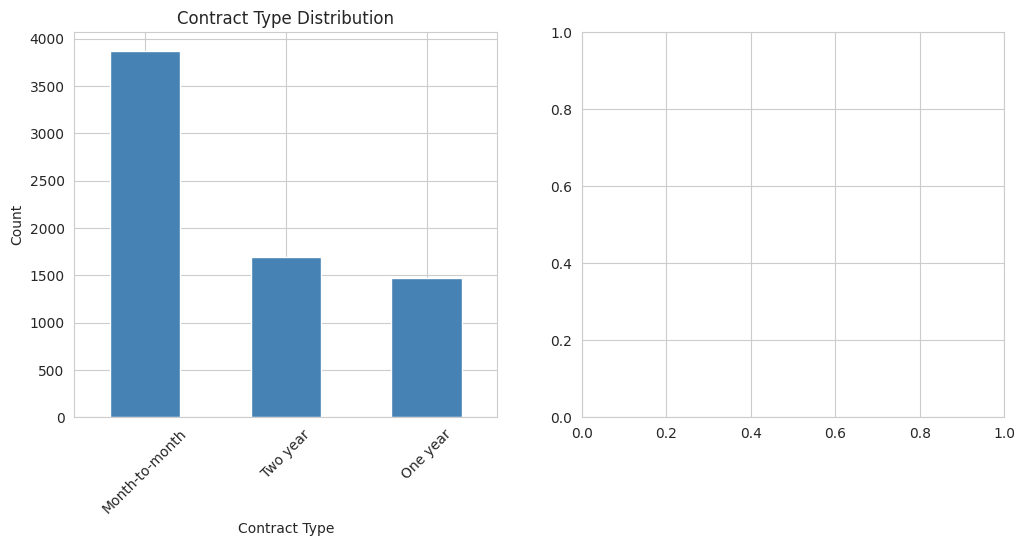

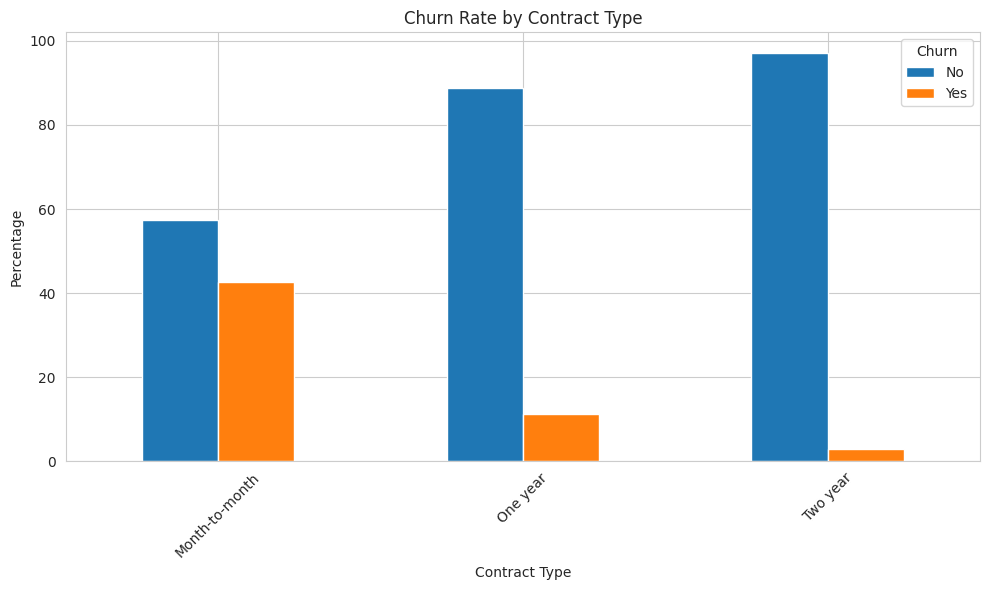

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['Contract'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Contract Type Distribution')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=False)
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.legend(title='Churn')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


SyntaxError: can't use starred expression here (397938634.py, line 9)

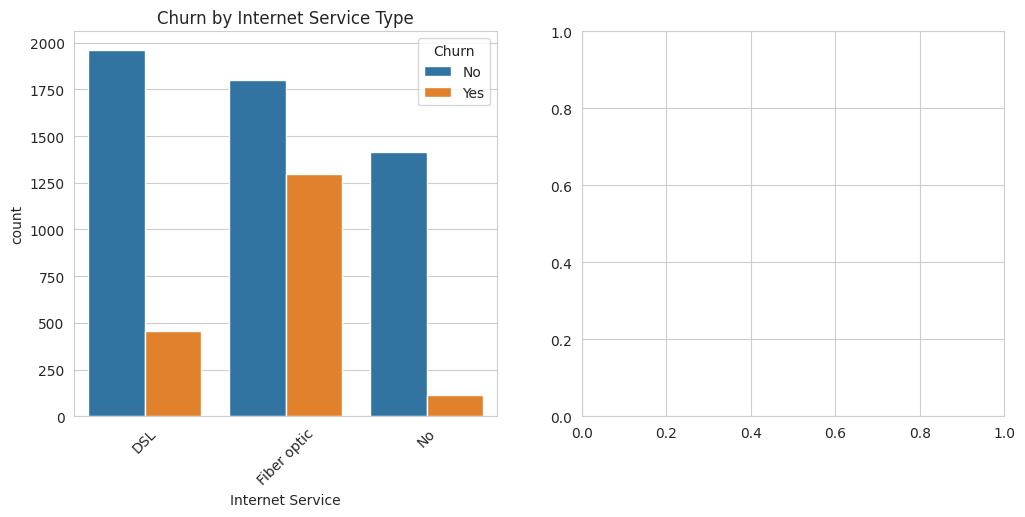

In [11]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')
* 100
internet_churn['Yes'].plot(kind='bar', color='coral')
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

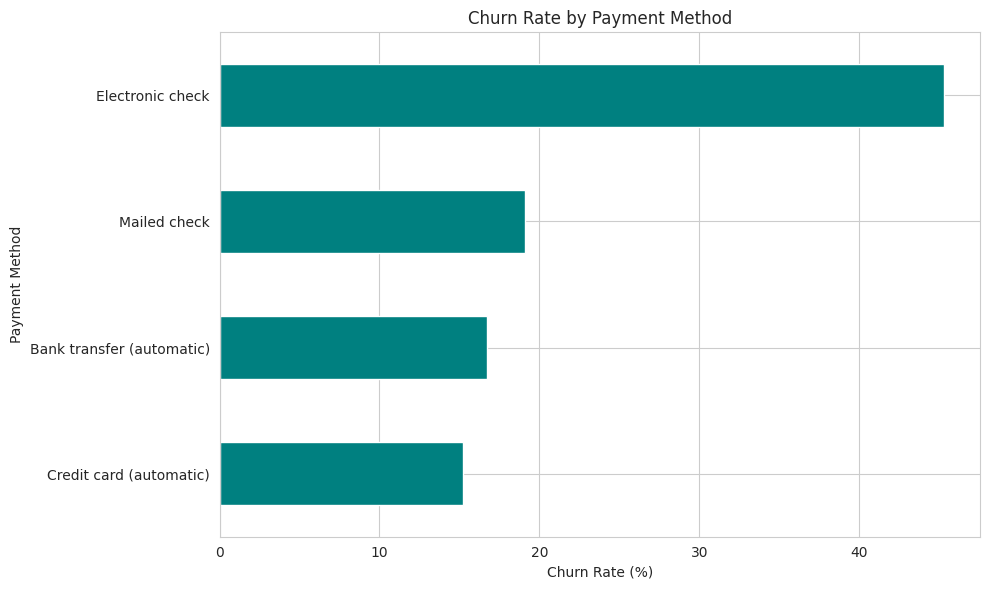

In [16]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')*100
plt.figure(figsize=(10, 6))
payment_churn['Yes'].sort_values().plot(kind='barh', color='teal')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Payment Method')
plt.tight_layout()
plt.show()


## 4. Feature Correlations

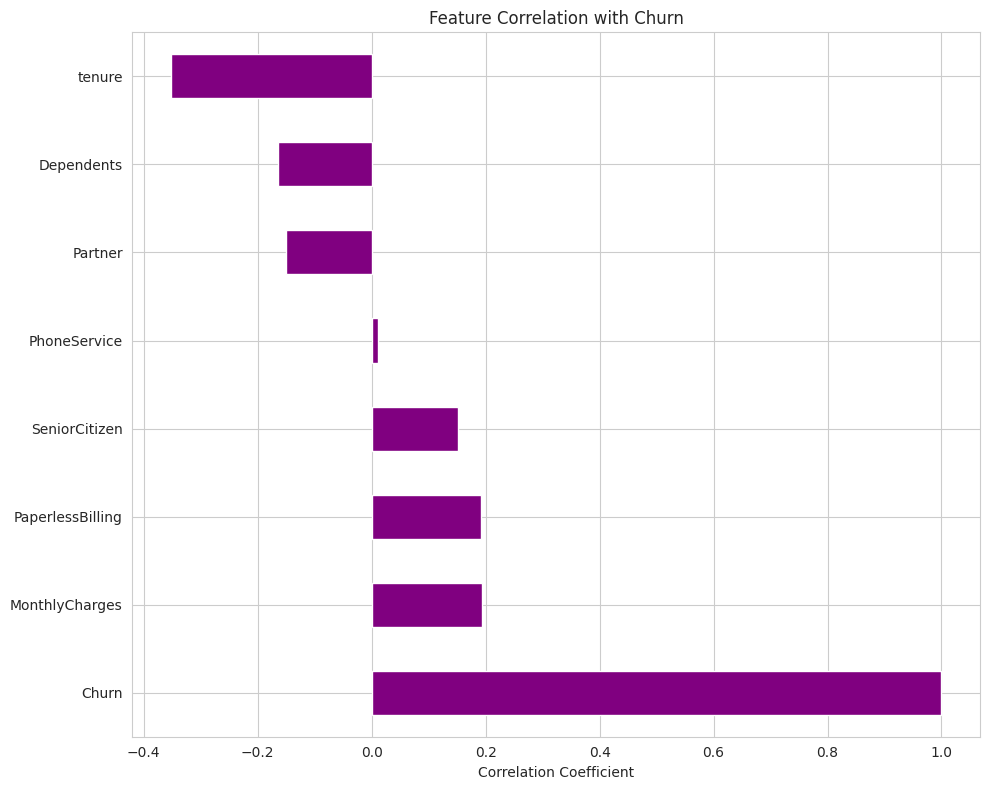

In [22]:
# Prepare numeric data
df_numeric = df.copy()
# Convert Yes/No to 1/0
binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
  if col in df_numeric.columns:
      df_numeric[col] = df_numeric[col].map({'Yes': 1, 'No': 0})
# Select only numeric columns
numeric_features = df_numeric.select_dtypes(include=[np.number])
# Correlation with Churn
plt.figure(figsize=(10, 8))
churn_corr = numeric_features.corr()['Churn'].sort_values(ascending=False)
churn_corr.plot(kind='barh', color='purple')
plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

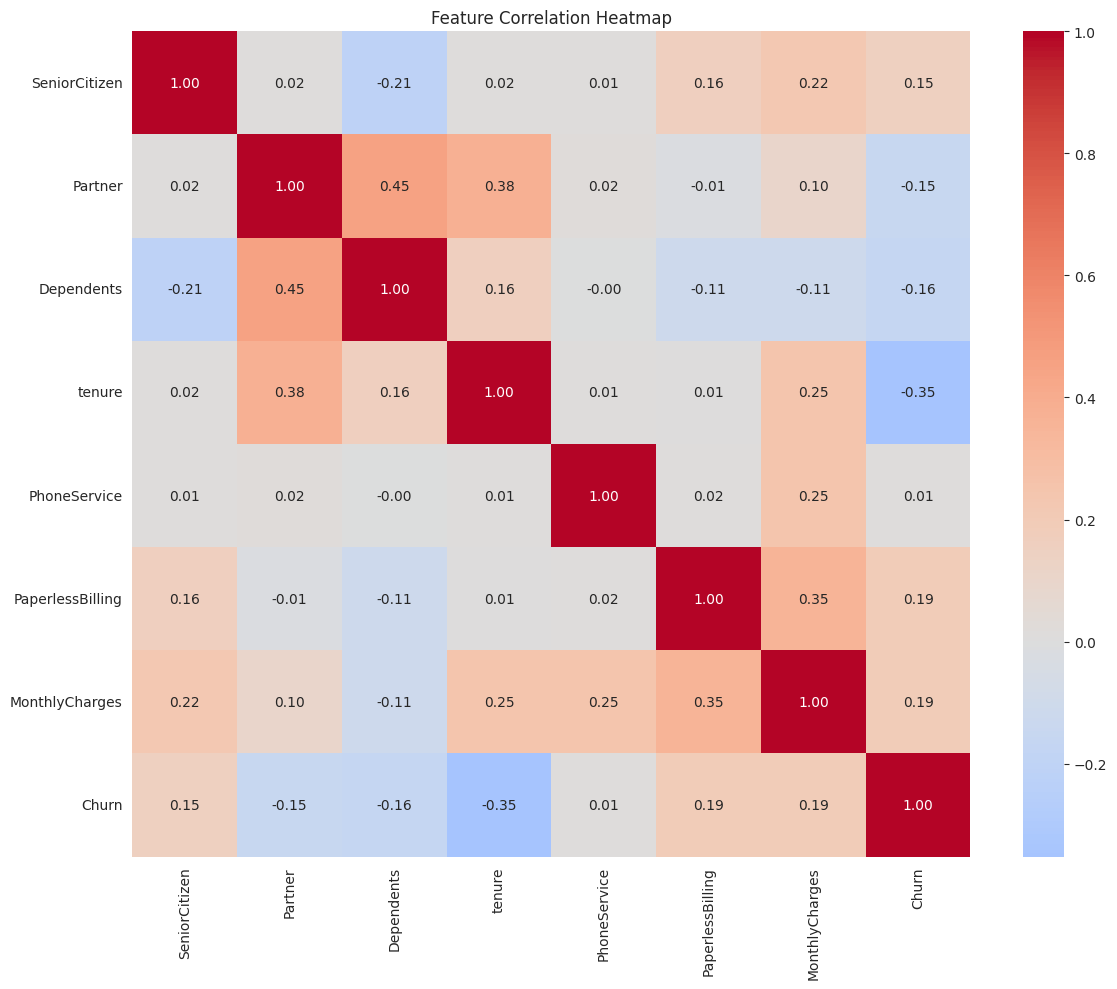

In [23]:
plt.figure(figsize=(12, 10))
correlation_matrix = numeric_features.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


PART 3: DOCUMENTATION & FINALIZATION

## 5. Key Insights and Findings
### High-Risk Customer Characteristics:
1. **Contract Type**: Month-to-month contracts have XX% churn rate (vs Y% for
yearly)
2. **Tenure**: Customers with <6 months tenure are high risk
3. **Charges**: Higher monthly charges correlate with higher churn
4. **Services**: Fiber optic internet users churn more than DSL
5. **Payment**: Electronic check users have higher churn
### Patterns Observed:- [Add 3-5 specific observations from your analysis]
### Recommendations for Feature Engineering:- Create 'TenureGroup' (0-12, 13-24, 25-48, 49+ months)- Flag 'HighMonthlyCharges' (>$70)- Count total services subscribed- Create 'ChargesPerService' ratio
### Questions for Next Week:- Which features should we include in the model?- How to handle categorical variables?- What about class imbalance (if churn rate is low)?

Report****

1. Core Dataset Metrics
Total Sample: 7,043 customers.

Churn Rate: 26.5% (High-intensity loss).

Key Data Types: Demographics, Account Settings, and Service Tiers.

2. Primary Risk Indicators
The analysis identifies five critical factors driving customer departure:

Contractual Status: Month-to-month contracts are the strongest predictor of churn. Long-term (1–2 year) contracts show significantly higher stability.

Customer Longevity: High vulnerability in the "New Customer" segment (<6 months tenure). Risk decreases sharply as tenure increases.

Service Infrastructure: Fiber Optic users churn at a higher rate than DSL users, suggesting a gap between cost and perceived value.

Financial Profile: Churners typically fall in the $70–$100/month range. Higher monthly bills correlate with higher exit rates.

Payment Friction: Electronic Check users exhibit disproportionately higher churn than those on automated payment systems.

3. Retention Drivers (Add-on Services)
The presence of "Utility Support" services acts as a primary anchor for customers. Lack of the following leads to higher churn:

Online Security

Tech Support

Online Backup

Device Protection

4. Strategic Recommendations
Incentivize Migration: Convert month-to-month users to annual contracts via discounts.

Targeted Onboarding: Implement high-touch engagement for customers in their first 90 days.

Payment Optimization: Encourage automated bank transfers or credit card payments to reduce the "bill shock" associated with manual electronic checks.

Service Bundling: Bundle Tech Support and Security features into high-tier internet plans to increase "stickiness."